## Preparando e treinando o modelo

### Importando bibliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from scipy.signal import hilbert
from scipy.stats import pearsonr, spearmanr

# Ignorar os avisos (warnings) do MNE para deixar o output mais limpo
warnings.filterwarnings('ignore')

### Fazendo merge das tabelas

In [4]:
df_demo = pd.read_csv('table/Demographics.csv')
df_bpi = pd.read_csv('table/BPI Answers.csv')
df_paindetect = pd.read_csv('table/PainDetect Answers.csv')

# Deixando as colunas ID com o mesmo tipo
df_demo['ID'] = df_demo['ID'].astype(str)
df_bpi['ID'] = df_bpi['ID'].astype(str)
df_paindetect['ID'] = df_paindetect['ID'].astype(str)

# Unindo as tabelas pelo ID
df_completo = pd.merge(df_demo, df_bpi, on='ID', how='inner')
df_completo = pd.merge(df_completo, df_paindetect, on='ID', how='inner')

df_completo = df_completo.dropna(subset=['Actual Pain'])

In [5]:
# Mostra as 5 primeiras linhas da tabela com todas as colunas
display(df_completo.head())

print(f"\nTotal de pacientes com notas de dor: {df_completo.shape[0]}")
print(f"Total de colunas mescladas: {df_completo.shape[1]}")

,ID,Pain Score (Actual Pain of Brief Pain Inventory),Age,Gender,Etiology of NP*,Time with NP,Medical treatment for NP,Since when have you use the previous medication?,Have you had any medical procedures to control the pain?,Do you go regularly to phsychological or emotional counseling sessions for your pain?,...,Please write your main area of pain,Does your pain radiate to other regions of your body?,"If the answer is yes, please write the direction in which it irradiates as explicitly as possible","Do you suffer from a burning sensation (e.g., stinging nettles) in the marked areas?",Do you have a tingling or prickling sensation in the area of your pain (like crawling ants or electrical tingling)?,"Is light touching (clothing, a blanket) in this area painful?","Do you have sudden pain attacks in the area of your pain, like electric shocks?",Is cold or heat (bath water) in this area occasionally painful?,Do you suffer from a sensation of numbness in the areas that you marked?,"Does slight pressure in this area, e.g., with a finger, trigger pain?"
0,0,7.0,25.0,F,Central Nervous System Disorder (CRPS or Lyme),More than 2 years,"Pregabalin, amitriptyline",More than a year ago,Nerve blocks and infusions*,Yes,...,Soles of feet and palms of hands,Yes,"From the feet to lower back, from the hands to...",Strongly,Strongly,Strongly,Very Strongly,Very Strongly,Strongly,Moderately
1,1,4.0,57.0,F,Diabetes,More than 2 years,Tramadol,More than a month ago,NaN,No,...,Sole of feet,No,NaN,Very Strongly,Strongly,Strongly,Strongly,Strongly,Strongly,Strongly
2,2,3.0,20.0,F,Peripheral neuropathy,More than 2 years,Keterolac,More than a year ago,NaN,No,...,Wrist and hand,Yes,From the wrist to the fingers,Never,Moderately,Never,Moderately,Strongly,Very Strongly,Slightly
3,3,8.0,34.0,F,Spinal cord or nerve root injury,More than 2 years,Tramadol,More than a year ago,Physiotherapy,No,...,Lower back,No,NaN,Strongly,Moderately,Never,Never,Moderately,Never,Very Strongly
4,4,5.0,77.0,M,Spinal cord or nerve root injury,More than 2 years,NaN,NaN,NaN,No,...,"Legs, back, neck and head",Yes,To the limbs,Never,Strongly,Never,Strongly,Never,Strongly,Strongly



Total de pacientes com notas de dor: 36
Total de colunas mescladas: 35


### Definição de bandas e pares de assimetria EEG

In [14]:
bandas = {
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 40)
}

pares_assimetria = {
    'Fp1': 'Fp2',
    'F3': 'F4',
    'C3': 'C4',
    'P3': 'P4',
    'O1': 'O2',
    'F7': 'F8',
    'T7': 'T8',
    'P7': 'P8'
}

X_features = []
y_labels = []
feature_names = []
pasta_eeg = './cleaned' 

### Loop de extração de features dos EEGs

In [15]:
for index, row in df_completo.iterrows():
    paciente_id = int(row['ID'])
    nota_dor = float(row['Actual Pain']) # Usando a dor do BPI como target
    
    nome_arquivo = f"ID{paciente_id}_preproc_eeg.fif"
    caminho = os.path.join(pasta_eeg, nome_arquivo)
    
    if os.path.exists(caminho):
        try:
            # Carregar EEG
            raw = mne.io.read_raw_fif(caminho, preload=True, verbose=False)
            todos_canais = raw.ch_names
            
            # Calcular PSD (Welch)
            psd = raw.compute_psd(fmin=4, fmax=40, method='welch', verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            features_paciente = []
            potencia_canais = {}
            nomes_temporarios = [] # Guarda os nomes apenas na primeira vez
            
            # POTÊNCIA DE BANDA INDIVIDUAL
            for i, canal in enumerate(todos_canais):
                potencia_canais[canal] = {}
                for nome_banda, (fmin, fmax) in bandas.items():
                    idx_banda = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                    potencia = np.sum(psd_data[i, idx_banda])
                    
                    potencia_canais[canal][nome_banda] = potencia
                    features_paciente.append(potencia)
                    
                    if not feature_names: # Só preenche os nomes na 1ª iteração válida
                        nomes_temporarios.append(f"Pow_{canal}_{nome_banda}")

            # ASSIMETRIA DOS HEMISFÉRIOS
            for canal_esq, canal_dir in pares_assimetria.items():
                if canal_esq in potencia_canais and canal_dir in potencia_canais:
                    for nome_banda in bandas.keys():
                        p_esq = potencia_canais[canal_esq][nome_banda]
                        p_dir = potencia_canais[canal_dir][nome_banda]
                        
                        assimetria = (p_dir - p_esq) / (p_dir + p_esq)
                        features_paciente.append(assimetria)
                        
                        if not feature_names:
                            nomes_temporarios.append(f"Asym_{canal_esq}-{canal_dir}_{nome_banda}")
            
            # Se for o primeiro paciente processado, salva os nomes das colunas
            if not feature_names:
                feature_names = nomes_temporarios
                
            X_features.append(features_paciente)
            y_labels.append(nota_dor)
            
            print(f"[OK] EEG do Paciente {paciente_id} processado com sucesso.")
            
        except Exception as e:
            print(f"[ERRO] Falha no paciente {paciente_id}: {e}")
            
X = np.array(X_features)
y = np.array(y_labels)

print(f"EXTRAÇÃO CONCLUÍDA:")
print(f"Total de pacientes processados com EEG e Tabela: {X.shape[0]}")
print(f"Total de Biomarcadores (Features) extraídos por paciente: {X.shape[1]}")

[OK] EEG do Paciente 0 processado com sucesso.
[OK] EEG do Paciente 1 processado com sucesso.
[OK] EEG do Paciente 2 processado com sucesso.
[OK] EEG do Paciente 3 processado com sucesso.
[OK] EEG do Paciente 4 processado com sucesso.
[OK] EEG do Paciente 5 processado com sucesso.
[OK] EEG do Paciente 6 processado com sucesso.
[OK] EEG do Paciente 7 processado com sucesso.
[OK] EEG do Paciente 8 processado com sucesso.
[OK] EEG do Paciente 9 processado com sucesso.
[OK] EEG do Paciente 10 processado com sucesso.
[OK] EEG do Paciente 11 processado com sucesso.
[OK] EEG do Paciente 13 processado com sucesso.
[OK] EEG do Paciente 14 processado com sucesso.
[OK] EEG do Paciente 15 processado com sucesso.
[OK] EEG do Paciente 16 processado com sucesso.
[OK] EEG do Paciente 18 processado com sucesso.
[OK] EEG do Paciente 19 processado com sucesso.
[OK] EEG do Paciente 20 processado com sucesso.
[OK] EEG do Paciente 21 processado com sucesso.
[OK] EEG do Paciente 22 processado com sucesso.
[O

### Machine Learning (seleção de features e modelos)

#### SVR

In [8]:
if X.shape[0] > 0:
    print("Avaliando o modelo de Machine Learning com Validação Cruzada (K-Fold)")
    
    # Reduzimos para 5 para evitar decorar os dados (Overfitting)
    num_features_selecionar = 5 
    
    # Criando o Pipeline (Escalonar -> Selecionar Top 5 -> Treinar SVM Linear)
    pipeline_ajustado = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=num_features_selecionar)),
        ('svr', SVR(kernel='linear', C=0.1, epsilon=0.1))
    ])
    
    # Configurando a Validação Cruzada K-Fold (divide o dataset em 5 partes)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculando as métricas médias nos 5 ciclos de teste
    scores_r2 = cross_val_score(pipeline_ajustado, X, y, cv=kf, scoring='r2')
    scores_rmse = cross_val_score(pipeline_ajustado, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    
    print("\nDESEMPENHO MÉDIO DO MODELO SVR (CROSS-VALIDATION)")
    print(f"R-quadrado (R²): {scores_r2.mean():.3f} (Desvio: {scores_r2.std():.3f})")
    print(f"RMSE (Erro médio da nota de dor): {-scores_rmse.mean():.3f}")

    pipeline_ajustado.fit(X, y)
    
    seletor = pipeline_ajustado.named_steps['selector']
    mascara = seletor.get_support()
    biomarcadores_finais = np.array(feature_names)[mascara]
    
    print(f"\nTOP {num_features_selecionar} BIOMARCADORES DEFINITIVOS PARA A DOR")
    for i, bio in enumerate(biomarcadores_finais, 1):
        print(f"{i}. {bio}")
        
else:
    print("Nenhum paciente processado. Verifique os caminhos dos arquivos .fif!")

Avaliando o modelo de Machine Learning com Validação Cruzada (K-Fold)

DESEMPENHO MÉDIO DO MODELO SVR (CROSS-VALIDATION)
R-quadrado (R²): -0.895 (Desvio: 0.711)
RMSE (Erro médio da nota de dor): 2.990

TOP 5 BIOMARCADORES DEFINITIVOS PARA A DOR
1. Asym_C3-C4_Beta
2. Asym_C3-C4_Gamma
3. Asym_P3-P4_Theta
4. Asym_P7-P8_Theta
5. Asym_P7-P8_Alpha


Gráfico salvo como 'Correlacoes_Biomarcadores_Dor.png'!


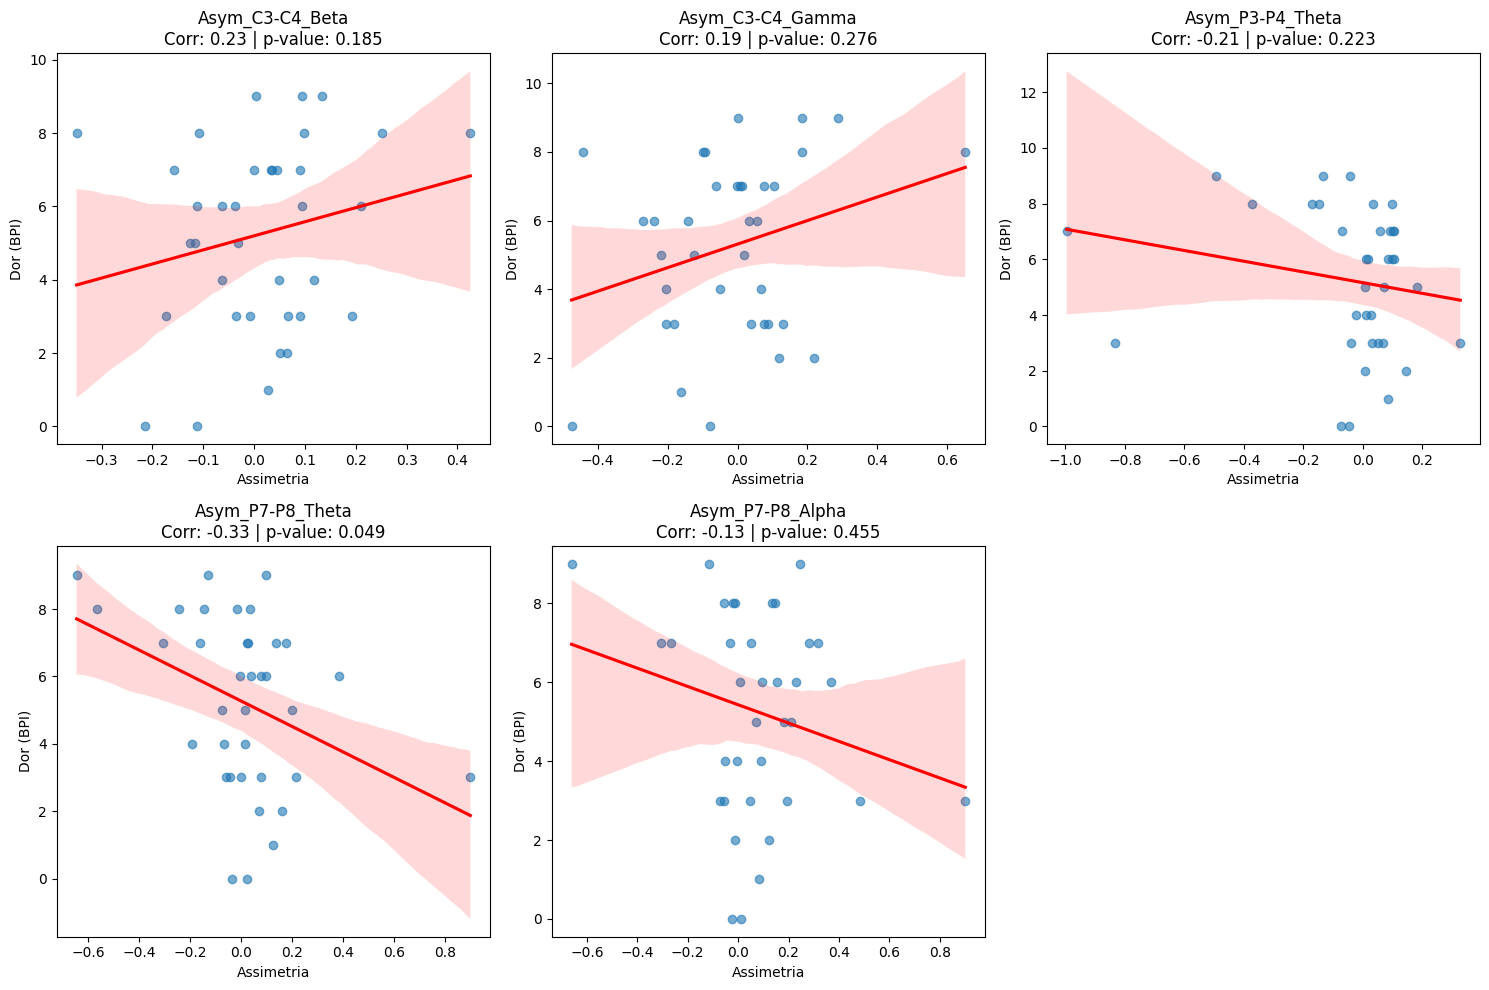

In [9]:
# Recuperar apenas as colunas das 5 melhores features
indices_top5 = np.where(mascara)[0]
X_top5 = X[:, indices_top5]

# Criar um DataFrame para facilitar os gráficos
df_resultados = pd.DataFrame(X_top5, columns=biomarcadores_finais)
df_resultados['Nota de Dor'] = y

# Plotar os gráficos de correlação
plt.figure(figsize=(15, 10))
for i, biomarcador in enumerate(biomarcadores_finais, 1):
    plt.subplot(2, 3, i)
    sns.regplot(data=df_resultados, x=biomarcador, y='Nota de Dor', 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    
    corr, p_value = spearmanr(df_resultados[biomarcador], df_resultados['Nota de Dor'])
    
    plt.title(f"{biomarcador}\nCorr: {corr:.2f} | p-value: {p_value:.3f}")
    plt.xlabel("Assimetria")
    plt.ylabel("Dor (BPI)")

plt.tight_layout()
plt.savefig("Correlacoes_Biomarcadores_Dor.png", dpi=300)
print("Gráfico salvo como 'Correlacoes_Biomarcadores_Dor.png'!")

#### Random Forest

In [10]:
if X.shape[0] > 0:
    print("Avaliando o modelo Random Forest com Validação Cruzada (K-Fold)...")
    
    num_features_selecionar = 5 
    
    # Criando o novo Pipeline com Random Forest
    pipeline_rf = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_regression, k=num_features_selecionar)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)) 
    ])
    
    # Configurando a Validação Cruzada K-Fold (divide o dataset em 5 partes)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculando as métricas médias nos 5 ciclos de teste
    scores_r2 = cross_val_score(pipeline_rf, X, y, cv=kf, scoring='r2')
    scores_rmse = cross_val_score(pipeline_rf, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    
    print("\nDESEMPENHO MÉDIO DO RANDOM FOREST (CROSS-VALIDATION)")
    print(f"R-quadrado (R²): {scores_r2.mean():.3f} (Desvio: {scores_r2.std():.3f})")
    print(f"RMSE (Erro médio da nota de dor): {-scores_rmse.mean():.3f}")
    

    pipeline_rf.fit(X, y)
    
    seletor = pipeline_rf.named_steps['selector']
    mascara = seletor.get_support()
    biomarcadores_finais = np.array(feature_names)[mascara]
    
    print(f"\nTOP {num_features_selecionar} BIOMARCADORES (SELECIONADOS PELO PIPELINE)")
    for i, bio in enumerate(biomarcadores_finais, 1):
        print(f"{i}. {bio}")
        
    importancias = pipeline_rf.named_steps['rf'].feature_importances_
    print(f"\nIMPORTÂNCIA DADA PELO RANDOM FOREST A CADA BIOMARCADOR")
    for bio, imp in zip(biomarcadores_finais, importancias):
        print(f"- {bio}: {imp*100:.1f}% de importância para a decisão do modelo")
        
else:
    print("Nenhum paciente processado. Verifique os caminhos dos arquivos .fif!")

Avaliando o modelo Random Forest com Validação Cruzada (K-Fold)...

DESEMPENHO MÉDIO DO RANDOM FOREST (CROSS-VALIDATION)
R-quadrado (R²): -0.805 (Desvio: 0.500)
RMSE (Erro médio da nota de dor): 2.948

TOP 5 BIOMARCADORES (SELECIONADOS PELO PIPELINE)
1. Asym_C3-C4_Beta
2. Asym_C3-C4_Gamma
3. Asym_P3-P4_Theta
4. Asym_P7-P8_Theta
5. Asym_P7-P8_Alpha

IMPORTÂNCIA DADA PELO RANDOM FOREST A CADA BIOMARCADOR
- Asym_C3-C4_Beta: 18.9% de importância para a decisão do modelo
- Asym_C3-C4_Gamma: 20.1% de importância para a decisão do modelo
- Asym_P3-P4_Theta: 22.3% de importância para a decisão do modelo
- Asym_P7-P8_Theta: 23.4% de importância para a decisão do modelo
- Asym_P7-P8_Alpha: 15.3% de importância para a decisão do modelo


#### Random Forest com margem de tolerância

In [11]:
# Definimos a nossa função de Acurácia Flexível
def acuracia_com_margem(y_true, y_pred, margem=1.5):
    # Calcula a diferença absoluta entre o gabarito e a previsão
    erros_absolutos = np.abs(y_true - y_pred)
    
    # Conta quantos erros foram menores ou iguais à nossa margem 
    acertos = np.sum(erros_absolutos <= margem)
    
    # Retorna a porcentagem de acertos
    return acertos / len(y_true)

# Transformamos essa função em um 'Scorer'
scorer_margem = make_scorer(acuracia_com_margem, margem=1.5) 

# Rodamos a Validação Cruzada usando essa nova métrica
print("Avaliando Regressão com Margem de Tolerância (+-1.5 pontos)")

pipeline_rf_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_regression, k=5)),
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_margem = cross_val_score(pipeline_rf_reg, X, y, cv=kf, scoring=scorer_margem)

print(f"Acurácia Flexível Média: {scores_margem.mean()*100:.1f}%")
print(f"Desvio nos testes: {scores_margem.std()*100:.1f}%")

Avaliando Regressão com Margem de Tolerância (+-1.5 pontos)
Acurácia Flexível Média: 24.6%
Desvio nos testes: 15.7%


#### Random Forest com Classification

In [12]:
if X.shape[0] > 0:
    print("Avaliando modelo de Classificação (Dor Intensa vs Leve/Moderada)...")
    
    # Transformar o alvo (y) de contínuo para binário (0 ou 1)
    # Dor >= 6 vira Classe 1 (Intensa). Dor < 6 vira Classe 0.
    y_class = np.where(y >= 6, 1, 0)
    
    print(f"\nDistribuição das classes:")
    print(f"- Pacientes com Dor Intensa (>=6): {sum(y_class == 1)}")
    print(f"- Pacientes com Dor Leve/Mod (<6): {sum(y_class == 0)}\n")

    num_features_selecionar = 5 
    
    # Criando o Pipeline com Random Forest CLASSIFIER
    pipeline_class = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=num_features_selecionar)), 
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42))
    ])
    
    # StratifiedKFold garante que a proporção de dor intensa/leve seja igual em todos os testes
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculando Acurácia e AUC-ROC
    scores_acc = cross_val_score(pipeline_class, X, y_class, cv=skf, scoring='accuracy')
    scores_auc = cross_val_score(pipeline_class, X, y_class, cv=skf, scoring='roc_auc')
    
    print("DESEMPENHO DO MODELO DE CLASSIFICAÇÃO (CROSS-VALIDATION)")
    print(f"Acurácia Média: {scores_acc.mean()*100:.1f}% (Desvio: {scores_acc.std()*100:.1f}%)")
    print(f"AUC-ROC Média: {scores_auc.mean():.3f}")
 
    pipeline_class.fit(X, y_class)
    
    seletor = pipeline_class.named_steps['selector']
    mascara = seletor.get_support()
    biomarcadores_finais = np.array(feature_names)[mascara]
    importancias = pipeline_class.named_steps['rf'].feature_importances_
    
    print(f"\nTOP {num_features_selecionar} BIOMARCADORES (CLASSIFICAÇÃO)")
    for bio, imp in zip(biomarcadores_finais, importancias):
        print(f"- {bio}: {imp*100:.1f}% de importância")

else:
    print("Nenhum paciente processado.")

Avaliando modelo de Classificação (Dor Intensa vs Leve/Moderada)...

Distribuição das classes:
- Pacientes com Dor Intensa (>=6): 19
- Pacientes com Dor Leve/Mod (<6): 17

DESEMPENHO DO MODELO DE CLASSIFICAÇÃO (CROSS-VALIDATION)
Acurácia Média: 24.6% (Desvio: 15.7%)
AUC-ROC Média: 0.242

TOP 5 BIOMARCADORES (CLASSIFICAÇÃO)
- Pow_P8_Beta: 16.7% de importância
- Pow_P8_Gamma: 18.9% de importância
- Asym_F3-F4_Theta: 16.9% de importância
- Asym_P7-P8_Theta: 23.5% de importância
- Asym_P7-P8_Alpha: 24.1% de importância


#### PAC (Acoplamento Fase-Amplitude) e XGBoost

In [19]:
from sklearn.impute import SimpleImputer

def compute_pac_mi(data, sfreq, f_phase, f_amp, n_bins=18):
    # Calcula o Acoplamento Fase-Amplitude (PAC) usando o Índice de Modulação (MI).
    
    # Converter para formato 2D exigido pelo MNE para filtragem
    data_2d = np.array([data], dtype=np.float64)
    
    # Filtrar o sinal para as frequências de Fase e Amplitude
    phase_signal = mne.filter.filter_data(data_2d, sfreq, l_freq=f_phase[0], h_freq=f_phase[1], verbose=False)[0]
    amp_signal = mne.filter.filter_data(data_2d, sfreq, l_freq=f_amp[0], h_freq=f_amp[1], verbose=False)[0]
    
    # Extrair a Fase e a Amplitude usando a Transformada de Hilbert
    phase = np.angle(hilbert(phase_signal))
    amp = np.abs(hilbert(amp_signal))
    
    # Binning (Agrupando as amplitudes baseado no ângulo da fase)
    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    bin_amp_mean = np.zeros(n_bins)
    
    for i in range(n_bins):
        idx = np.where((phase >= bins[i]) & (phase < bins[i+1]))[0]
        if len(idx) > 0:
            bin_amp_mean[i] = np.mean(amp[idx])
            
    # Normalizar as amplitudes para criar uma distribuição de probabilidade
    soma_amp = np.sum(bin_amp_mean)
    if soma_amp == 0:
        return 0
    p_j = bin_amp_mean / soma_amp
    
    # Calcular o Índice de Modulação (Entropia de Shannon vs Entropia Máxima)
    h_max = np.log(n_bins)
    h = -np.sum(p_j[p_j > 0] * np.log(p_j[p_j > 0]))
    
    mi = (h_max - h) / h_max
    return mi

pares_pac = [
    ('Theta', 'Beta'),
    ('Theta', 'Gamma'),
    ('Alpha', 'Beta'),
    ('Alpha', 'Gamma')
]

canais_alvo = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

X_features = []
y_labels = []
feature_names = []

print("Iniciando extração profunda (PSD + PAC + Assimetrias) com padronização de matriz...")

for index, row in df_completo.iterrows():
    paciente_id = int(float(row['ID'])) 
    nota_dor = float(row['Actual Pain']) 
    caminho = os.path.join(pasta_eeg, f"ID{paciente_id}_preproc_eeg.fif")
    
    if os.path.exists(caminho):
        try:
            raw = mne.io.read_raw_fif(caminho, preload=True, verbose=False)
            todos_canais = raw.ch_names
            sfreq = raw.info['sfreq']
            
            # Matriz bruta de dados para o cálculo do PAC (Canais x Tempo)
            dados_brutos = raw.get_data()
            
            psd = raw.compute_psd(fmin=4, fmax=40, method='welch', verbose=False)
            psd_data, freqs = psd.get_data(return_freqs=True)
            
            features_paciente = []
            potencia_canais = {}
            pac_canais = {}
            nomes_temporarios = [] 
            
            # LOOP CANAL POR CANAL (Baseado na lista FIXA)
            for canal in canais_alvo:
                if canal in todos_canais:
                    i = todos_canais.index(canal)
                    sinal_do_canal = dados_brutos[i, :]
                    
                    # Potência Convencional 
                    potencia_canais[canal] = {}
                    for nome_banda, (fmin, fmax) in bandas.items():
                        idx_banda = np.where((freqs >= fmin) & (freqs <= fmax))[0]
                        potencia = np.sum(psd_data[i, idx_banda])
                        potencia_canais[canal][nome_banda] = potencia
                        features_paciente.append(potencia)
                        if not feature_names: nomes_temporarios.append(f"Pow_{canal}_{nome_banda}")
                
                    # Acoplamento PAC
                    pac_canais[canal] = {}
                    for (f_phase, f_amp) in pares_pac:
                        mi = compute_pac_mi(sinal_do_canal, sfreq, bandas[f_phase], bandas[f_amp])
                        nome_pac = f"{f_phase}-{f_amp}"
                        pac_canais[canal][nome_pac] = mi
                        features_paciente.append(mi)
                        if not feature_names: nomes_temporarios.append(f"PAC_{canal}_{nome_pac}")
                        
                else:
                    # CORREÇÃO: Se o canal não existe no paciente, preencher com NaN
                    for nome_banda in bandas.keys():
                        features_paciente.append(np.nan)
                        if not feature_names: nomes_temporarios.append(f"Pow_{canal}_{nome_banda}")
                        
                    for (f_phase, f_amp) in pares_pac:
                        features_paciente.append(np.nan)
                        nome_pac = f"{f_phase}-{f_amp}"
                        if not feature_names: nomes_temporarios.append(f"PAC_{canal}_{nome_pac}")

            # LOOP DE ASSIMETRIAS ENTRE HEMISFÉRIOS
            for canal_esq, canal_dir in pares_assimetria.items():
                if canal_esq in potencia_canais and canal_dir in potencia_canais:
                    
                    # Assimetria de Potência
                    for nome_banda in bandas.keys():
                        p_esq = potencia_canais[canal_esq][nome_banda]
                        p_dir = potencia_canais[canal_dir][nome_banda]
                        assimetria = (p_dir - p_esq) / (p_dir + p_esq)
                        features_paciente.append(assimetria)
                        if not feature_names: nomes_temporarios.append(f"Asym_Pow_{canal_esq}-{canal_dir}_{nome_banda}")
                    
                    # Assimetria de PAC
                    for (f_phase, f_amp) in pares_pac:
                        nome_pac = f"{f_phase}-{f_amp}"
                        p_esq_pac = pac_canais[canal_esq][nome_pac]
                        p_dir_pac = pac_canais[canal_dir][nome_pac]
                        
                        if (p_dir_pac + p_esq_pac) == 0:
                            assimetria_pac = 0
                        else:
                            assimetria_pac = (p_dir_pac - p_esq_pac) / (p_dir_pac + p_esq_pac)
                        
                        features_paciente.append(assimetria_pac)
                        if not feature_names: nomes_temporarios.append(f"Asym_PAC_{canal_esq}-{canal_dir}_{nome_pac}")
                        
                else:
                    for nome_banda in bandas.keys():
                        features_paciente.append(np.nan)
                        if not feature_names: nomes_temporarios.append(f"Asym_Pow_{canal_esq}-{canal_dir}_{nome_banda}")
                    
                    for (f_phase, f_amp) in pares_pac:
                        features_paciente.append(np.nan)
                        nome_pac = f"{f_phase}-{f_amp}"
                        if not feature_names: nomes_temporarios.append(f"Asym_PAC_{canal_esq}-{canal_dir}_{nome_pac}")
            
            if not feature_names: feature_names = nomes_temporarios
            X_features.append(features_paciente)
            y_labels.append(nota_dor)
            
            print(f"[OK] EEG do Paciente {paciente_id} finalizado.")
            
        except Exception as e:
            print(f"[ERRO] Falha no paciente {paciente_id}: {e}")
  
X = np.array(X_features)
y = np.array(y_labels)

print("\n EXTRAÇÃO CONCLUÍDA")
print(f"Total de Biomarcadores (Pow + PAC + Assimetrias) gerados: {X.shape[1]}")

colunas_validas = ~np.isnan(X).all(axis=0) # Cria máscara de colunas boas
X = X[:, colunas_validas]                  # Filtra a matriz X
feature_names = np.array(feature_names)[colunas_validas].tolist() # Filtra os nomes

print(f"Biomarcadores úteis após remover canais 100% ausentes: {X.shape[1]}")

if X.shape[0] > 0:
    print("Avaliando modelo XGBoost com a matriz de features")
    
    y_class = np.where(y >= 6, 1, 0)
    num_features_selecionar = 7 
    
    # Criando o Pipeline com XGBoost 
    pipeline_xgb = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=num_features_selecionar)), 
        ('xgb', XGBClassifier(
            n_estimators=100,
            max_depth=3,           # Mantém as árvores rasas para evitar overfitting
            learning_rate=0.05,    # Aprende bem devagar e com calma
            reg_alpha=1.0,         # Regularização L1 (Lasso): Zera features inúteis
            reg_lambda=1.0,        # Regularização L2 (Ridge): Impede pesos absurdos
            random_state=42,
            eval_metric='logloss'  # Métrica de avaliação padrão silenciosa
        ))
    ])
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores_acc = cross_val_score(pipeline_xgb, X, y_class, cv=skf, scoring='accuracy')
    scores_auc = cross_val_score(pipeline_xgb, X, y_class, cv=skf, scoring='roc_auc')
    
    print("\nDESEMPENHO DO MODELO XGBOOST (CROSS-VALIDATION)")
    print(f"Acurácia Média: {scores_acc.mean()*100:.1f}%")
    print(f"AUC-ROC Média: {scores_auc.mean():.3f}")
    
    pipeline_xgb.fit(X, y_class)
    
    seletor = pipeline_xgb.named_steps['selector']
    mascara = seletor.get_support()
    biomarcadores_finais = np.array(feature_names)[mascara]
    importancias = pipeline_xgb.named_steps['xgb'].feature_importances_
    
    print(f"\nTOP {num_features_selecionar} BIOMARCADORES TOTAIS (XGBOOST)")
    for bio, imp in zip(biomarcadores_finais, importancias):
        print(f"- {bio}: {imp*100:.1f}% de importância")

else:
    print("Nenhum paciente processado.")

Iniciando extração profunda (PSD + PAC + Assimetrias) com padronização de matriz...
[OK] EEG do Paciente 0 finalizado.
[OK] EEG do Paciente 1 finalizado.
[OK] EEG do Paciente 2 finalizado.
[OK] EEG do Paciente 3 finalizado.
[OK] EEG do Paciente 4 finalizado.
[OK] EEG do Paciente 5 finalizado.
[OK] EEG do Paciente 6 finalizado.
[OK] EEG do Paciente 7 finalizado.
[OK] EEG do Paciente 8 finalizado.
[OK] EEG do Paciente 9 finalizado.
[OK] EEG do Paciente 10 finalizado.
[OK] EEG do Paciente 11 finalizado.
[OK] EEG do Paciente 13 finalizado.
[OK] EEG do Paciente 14 finalizado.
[OK] EEG do Paciente 15 finalizado.
[OK] EEG do Paciente 16 finalizado.
[OK] EEG do Paciente 18 finalizado.
[OK] EEG do Paciente 19 finalizado.
[OK] EEG do Paciente 20 finalizado.
[OK] EEG do Paciente 21 finalizado.
[OK] EEG do Paciente 22 finalizado.
[OK] EEG do Paciente 23 finalizado.
[OK] EEG do Paciente 24 finalizado.
[OK] EEG do Paciente 25 finalizado.
[OK] EEG do Paciente 26 finalizado.
[OK] EEG do Paciente 27 fi